<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 9.3 - LSTMs and Transformers for Sequence Prediction

LSTMs (Long Short-Term Memory networks) and Transformers are two powerful deep learning architectures designed to process sequential data.

LSTMs, a type of recurrent neural network (RNN), are capable of learning long-term dependencies by maintaining memory over time, making them effective for tasks like time series forecasting and language modeling. Transformers represent a more recent and revolutionary approach that relies entirely on attention mechanisms rather than recurrence. This allows them to process entire sequences in parallel and capture global relationships more efficiently. Both models play a crucial role in generative AI, enabling systems to understand, generate, and predict sequences—whether in text, audio, or time-based data like sensor readings or even stock prices.

Transformers can be expensive to train on text so in this lab we look at a smaller example of training on numerical sequences, namely a family of wave functions. The goal will be to use LSTM and transformer models to learn these patterns for the purpose of predicting the next values. In this lab we predict the future values all at once.

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Generating a dataset of waves

In the following function `seq_len` represents the length of the sequence up to prediction time, `pred_len` is number of samples to be predicted at once and `n_samples` the number of waves (of length `seq_len + pred_len`) generated by the function.

In [2]:
def generate_wave_data(seq_len=50, pred_len=10, n_samples=1000, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X, y = [], []
    for _ in range(n_samples):
        offset = np.random.rand() # Random shift to the wave

        t = np.linspace(offset, offset + (seq_len + pred_len) * 0.1, seq_len + pred_len)

        series = np.sin(2 * np.pi * t / 2.5) + 0.5 * np.sin(2 * np.pi * t)
        X.append(series[:seq_len])
        y.append(series[seq_len:])
    return np.array(X)[..., np.newaxis], np.array(y) # ..., np.newaxis adds a new dimension to X, making it 3-dimensional (samples, time_steps, features)

Next we prepare training, validation and test sets.

In [3]:
X, y = generate_wave_data(seed=99)
X_train, y_train = X[:800], y[:800]
X_val, y_val = X[800:], y[800:]

X_test, y_test = generate_wave_data(n_samples=5, seed=75)

In [4]:
X.shape #1000 waves, each with 50 values and 1 feature per time step

(1000, 50, 1)

Let us plot one of these samples:

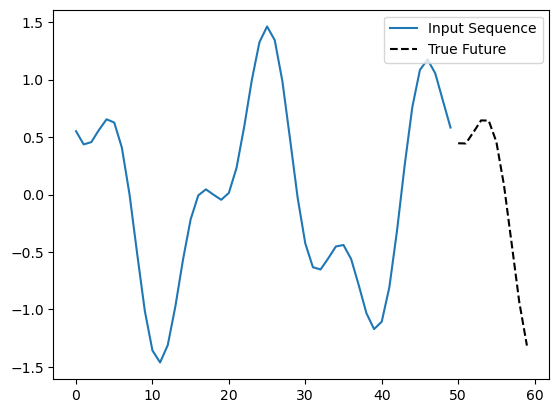

In [5]:
plt.figure()#figsize=(12, 10))
plt.plot(range(50), X_train[0].squeeze(), label="Input Sequence"); #.squeeze() removes the last dimension so that it is 1-dimensional
plt.plot(range(50, 60), y_train[0], 'k--', label="True Future");
plt.legend(loc="upper right");

**Exercise**: Plot two more samples of X_train to verify that they have the same shape but different shifts in time.

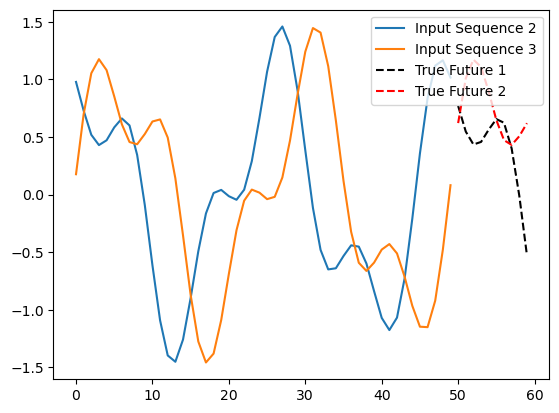

In [6]:
# ANSWER

plt.figure()
plt.plot(range(50), X_train[1].squeeze(), label="Input Sequence 2");
plt.plot(range(50), X_train[3].squeeze(), label="Input Sequence 3");

plt.plot(range(50, 60), y_train[1], 'k--', label="True Future 1");
plt.plot(range(50, 60), y_train[3], 'r--', label="True Future 2");
plt.legend(loc="upper right");

## LSTM Model

We start with a single-layer LSTM model with 16 cells. The output dense layer indicates that we are predicting the next ten values simultaneously.

In [7]:
lstm_model = keras.Sequential()
lstm_model.add(layers.Input(shape=X_train.shape[1:])) # X_train.shape[1:] = (50, 1)
lstm_model.add(layers.LSTM(16))
lstm_model.add(layers.Dense(10))


lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,322 (5.16 KB)

 Trainable params: 1,322 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

Let us understand why the number of parameters is as it is:

Each LSTM cell has four places where trainable weights are involved:
* Forget gate (deciding what information to discard from the long-term state)
* Input gate (deciding what new information to add to the long-term state)
* Cell update (new candidate values to add to the state)
* Output gate (deciding what part of the cell state to output)

In each case a matrix of size $H×(D+H)$ and bias vector of length $H$ is to be learnt (mapping the state-input vector [h,x] to new state vector h) where
* $H = 16$ (number of LSTM cells) and
* $D = 1$ (number of input features)


Hence #Params $=4×(H×(D+H)+H) = 4×(16×17+16) = 1152$

The 16-cell LSTM outputs a 16-dimensional vector. For the output layer, there are 10 neurons densely connected (hence $16×10 = 160$ weights with an additional $10$ bias terms).

Next, use the fit method of `lstm_model` to train the model on X_train, y_train for 10 epochs with validation_data = (X_val, y_val). You can increase the number of epochs if you wish to reduce the validation loss further.

In [8]:
# ANSWER

lstm_model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), verbose=1)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.5143 - val_loss: 0.4617
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4114 - val_loss: 0.3393
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2659 - val_loss: 0.1858
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1362 - val_loss: 0.0957
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0700 - val_loss: 0.0515
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0390 - val_loss: 0.0302
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0238 - val_loss: 0.0192
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0161 - val_loss: 0.0141
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0126 - val_loss: 0.0120
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0110 - val_loss: 0.0106


Use the predict method of `lstm_model` to make predictions on `X_test`:

In [9]:
# ANSWER

lstm_preds = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


## Graphs of sample predictions

Upon running the cell below you should see that the output predictions are relatively poor.

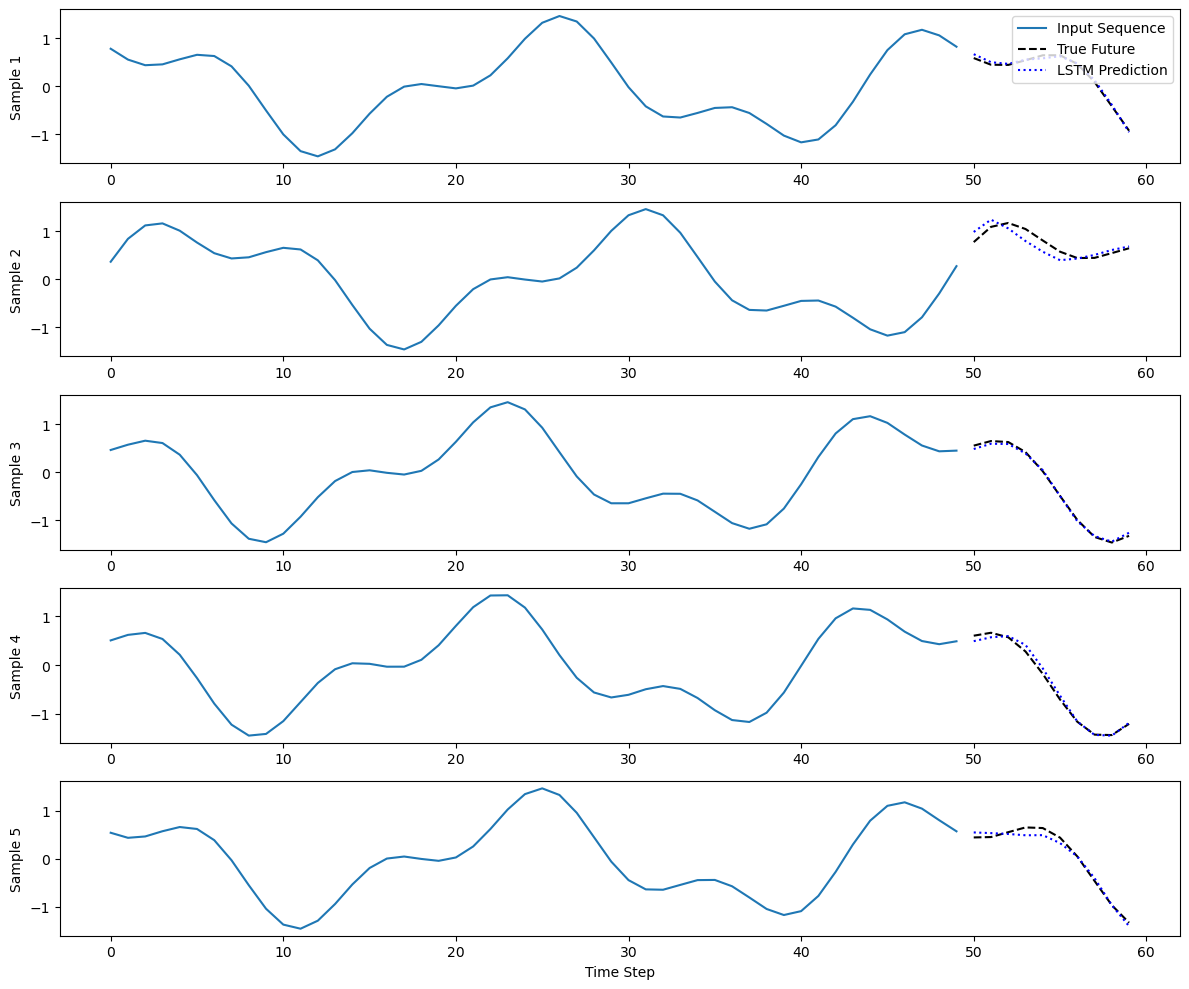

In [10]:
plt.figure(figsize=(12, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(range(50), X_test[i].squeeze(), label="Input Sequence") #.squeeze removes the last dimension so that it is 1-dimensional
    plt.plot(range(50, 60), y_test[i], 'k--', label="True Future")
    plt.plot(range(50, 60), lstm_preds[i], 'b:', label="LSTM Prediction")
    plt.ylabel(f"Sample {i+1}")
    if i == 0:
        plt.legend(loc="upper right")

plt.xlabel("Time Step")
plt.tight_layout()
plt.show()

**Exercise**: Improve the fit of the model by copying the model created above, then adding more LSTM layers (using `return_sequences=True` in all layers but the last) and having more cells per layer (currently there are 16 cells in the one LSTM layer). The final `layers.Dense(10)` should remain. Recompile and fit your model, aiming for a validation loss below 0.05.

In [11]:
# ANSWER - build and compile model

lstm_model = keras.Sequential()
lstm_model.add(layers.Input(shape=X_train.shape[1:])) #X_train.shape[1:] = (50, 1)
lstm_model.add(layers.LSTM(64, return_sequences=True))
lstm_model.add(layers.LSTM(32, return_sequences=True))
lstm_model.add(layers.LSTM(16))
lstm_model.add(layers.Dense(10))


lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,618 (127.41 KB)

 Trainable params: 32,618 (127.41 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ANSWER - fit model and calculate predictions

lstm_model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)
lstm_preds = lstm_model.predict(X_test)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.3726 - val_loss: 0.2514
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1734 - val_loss: 0.0972
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0633 - val_loss: 0.0379
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0250 - val_loss: 0.0149
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0102 - val_loss: 0.0071
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0048 - val_loss: 0.0034
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0029 - val_loss: 0.0024
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 11/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 12/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 8.8

The code below plots the LSTM predictions and true future for your new model.

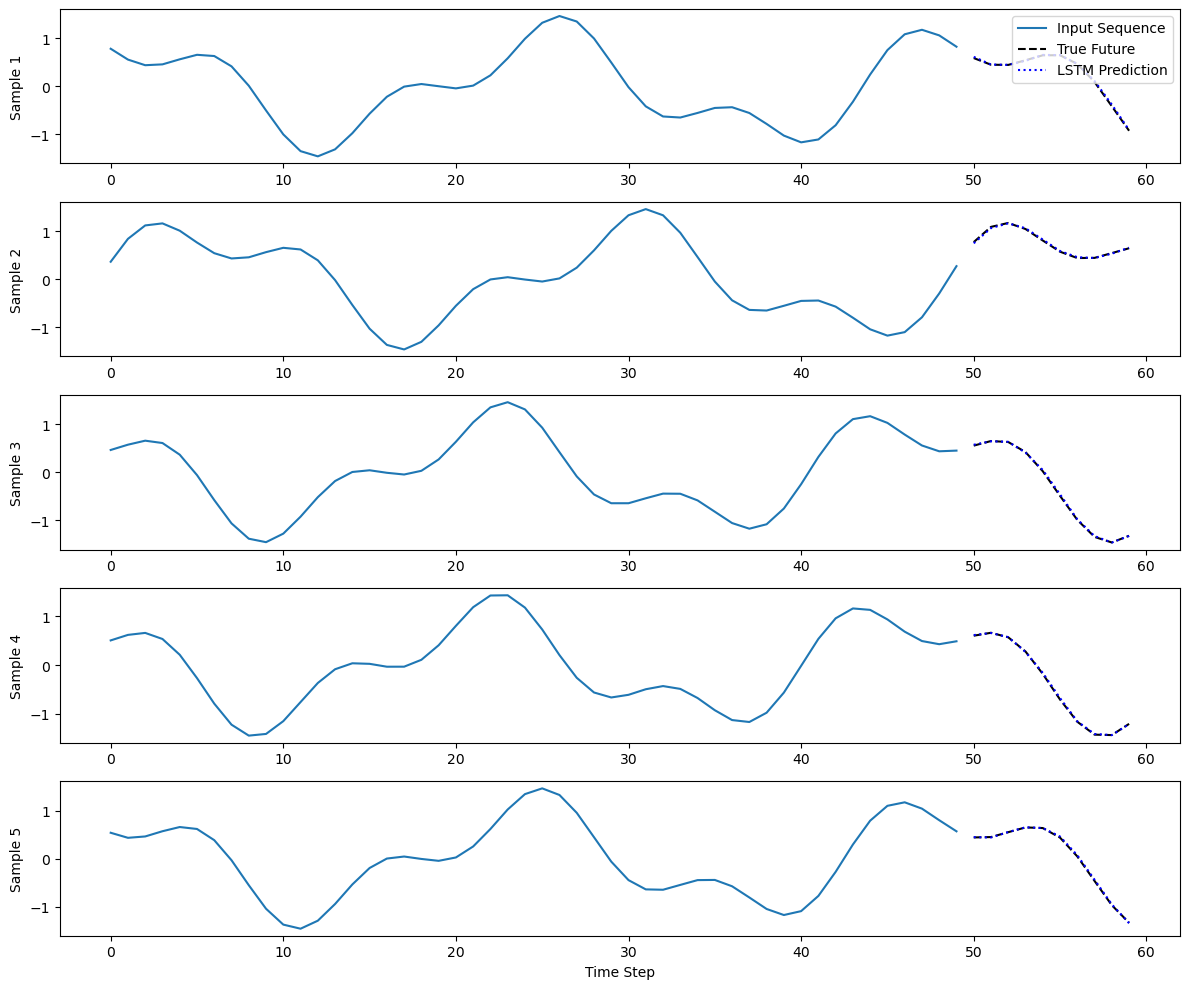

In [13]:
# plot predictions and true future values
plt.figure(figsize=(12, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(range(50), X_test[i].squeeze(), label="Input Sequence")
    plt.plot(range(50, 60), y_test[i], 'k--', label="True Future")
    plt.plot(range(50, 60), lstm_preds[i], 'b:', label="LSTM Prediction")
    plt.ylabel(f"Sample {i+1}")
    if i == 0:
        plt.legend(loc="upper right")

plt.xlabel("Time Step")
plt.tight_layout()
plt.show()

## Transformer Model

Note that forecasting requires an encoder-only model. If we wished to do machine translation or text summarisation, we would require an encoder-decoder model.


The following components make up the encoder-only transformer model here:

1. mapping the input sequence to an embedding space of size d_model (we use a feed-forward network to learn this mapping)
2. positional encoding (injecting information about the order of elements in the input sequence)
3. multi-head attention layer - this calculates attention scores between the sequence and itself, one 2D array of scores for each head
4. feedforward network - allows the model to learn richer patterns after combining information from other positions via attention
5. average pooling - provides one summary vector per input sequence
6. final feedforward layer - maps vector summary to a 10-dimensional output (the next 10 terms of the sequence)

Optionally residual connections and layer normalisation can be used (especially in deeper networks) to improve the training speed (better flow of gradients).

In [14]:
def build_transformer_seq2seq_model(input_shape, output_steps, d_model=8, num_heads=2, ff_dim=8, pos_encoding_flag=True):
  #d_model - number of dimensions of input and output vectors in transformer layers - must be divisible by num_heads
  #ff_dim  - feed forward network number of neurons
    inputs = keras.Input(shape=input_shape)

    # project to embedding space via a dense layer with d_model neurons
    x = layers.Dense(d_model)(inputs)

    # apply positional encoding
    if pos_encoding_flag == True:
      x = PositionalEncoding(seq_len=input_shape[0], d_model=d_model)(x)

    # apply multi-head self-attention layer (calculate attention scores between x and itself)
    x, attn_scores = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x, return_attention_scores=True)

    # skip connection and layer normlisation
    # x = layers.Add()([x, inputs])
    # x = layers.LayerNormalization()(x)

    # feedforward network
    ffn = keras.Sequential([
        layers.Dense(ff_dim, activation='relu'),
        # layers.Dense(ff_dim, activation='relu'),
        layers.Dense(d_model)
    ])

    x = ffn(x)
    # skip connection and layer normalisation
    # x = layers.Add()([x, ffn(x)])
    # x = layers.LayerNormalization()(x)

    # global average pooling gives one summary vector per input sequence
    x = layers.GlobalAveragePooling1D()(x)

    # apply a dense fully connected layer to give a 10-dimensional output
    output = layers.Dense(output_steps)(x)

    train_model = keras.Model(inputs, outputs = output)
    analysis_model = keras.Model(inputs, outputs = [output, attn_scores])

    #model.compile(optimizer='adam', loss='mse')
    return train_model, analysis_model



The following class defines the positional encoding block where trigonometric functions provide information about the order of the input sequence.

In [15]:
# this is not yet in core keras (only keras-nlp)
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model):
        super().__init__() #calls the __init__ method of the parent class layers.Layer
        pos = np.arange(seq_len)[:, np.newaxis] #shape (50, 1)
        i = np.arange(d_model)[np.newaxis, :] #shape (1, 50)
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        angle_rads = pos * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.pos_encoding = tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32) #reshaping to (batch_size, seq_len, d_model)

    def call(self, x): # in a keras layer subclass, a call() method defines the computation the layer performs when it is used in a model
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]


Building and compiling a model with mostly default settings:

In [16]:
train_model, analysis_model = build_transformer_seq2seq_model(X_train.shape[1:], output_steps=10)
train_model.compile(optimizer='adam', loss='mse')


In [17]:
train_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50, 8)     │         16 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 50, 8)     │          0 │ dense_2[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 50, 8),   │        568 │ positional_encod… │
│ (MultiHeadAttentio… │ (None, 2, 50,     │            │ positional_encod… │
│                     │ 50)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 50, 8)     │        144 │ multi_head_atten… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 8)         │          0 │ sequential_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │         90 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 818 (3.20 KB)

 Trainable params: 818 (3.20 KB)

 Non-trainable params: 0 (0.00 B)

Note that most of the parameters here are in the multi-head-attention block (query, key and value matrices for each attention block).

The next cell fits the model and calculates both predictions and attention scores

In [18]:
train_model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32, verbose=1)

transformer_preds, attn_scores = analysis_model.predict(X_test)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.5237 - val_loss: 0.4336
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4109 - val_loss: 0.3869
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3753 - val_loss: 0.3573
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3504 - val_loss: 0.3365
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3328 - val_loss: 0.3212
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3205 - val_loss: 0.3114
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3125 - val_loss: 0.3048
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3075 - val_loss: 0.3020
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3042 - val_loss: 0.2995
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3027 - val_loss: 0.2987
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3019 - val_loss: 0.2982
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.30

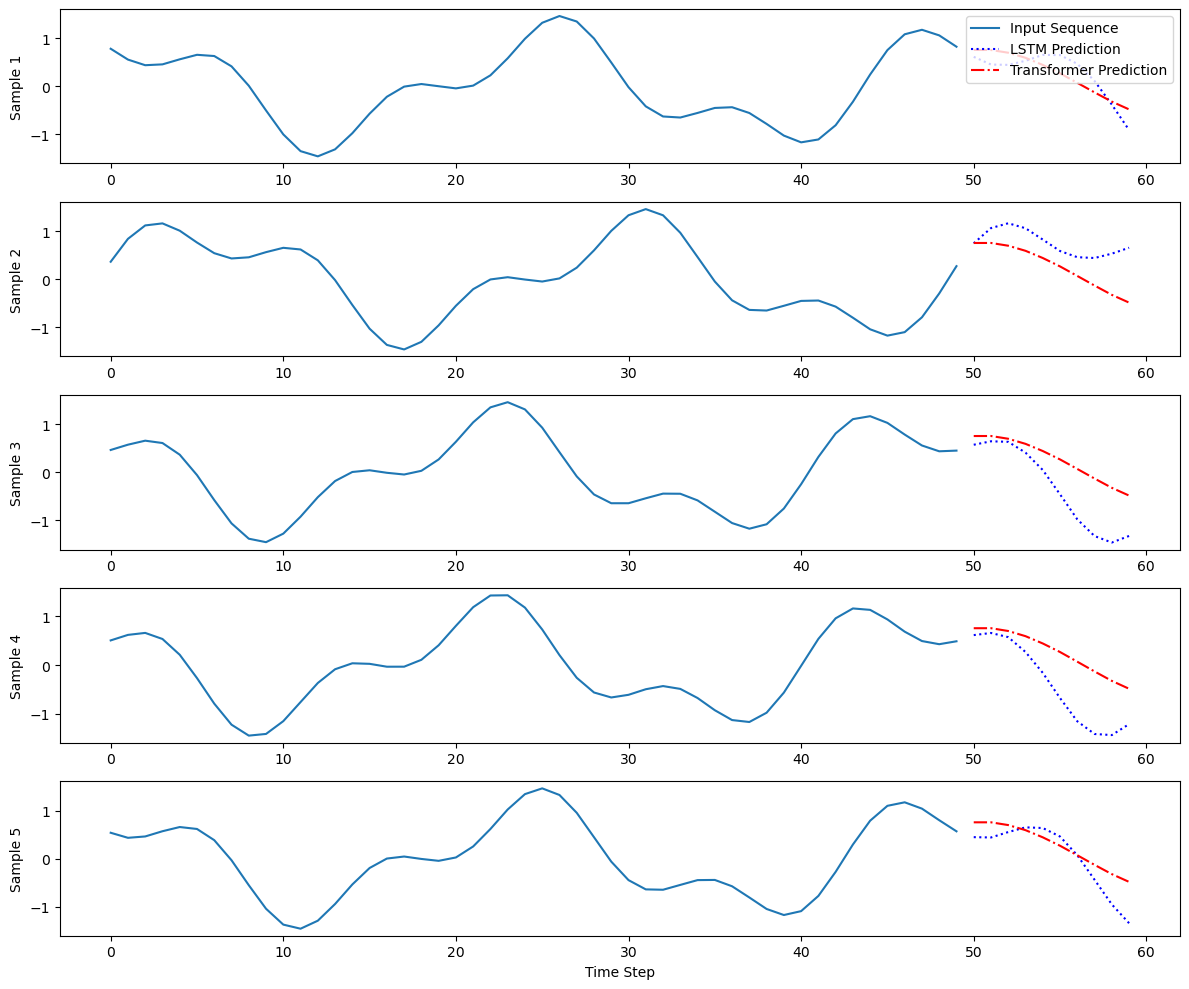

In [19]:
plt.figure(figsize=(12, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(range(50), X_test[i].squeeze(), label="Input Sequence") #.squeeze removes the last dimension so that it is 1-dimensional
    plt.plot(range(50, 60), lstm_preds[i], 'b:', label="LSTM Prediction")
    plt.plot(range(50, 60), transformer_preds[i], 'r-.', label="Transformer Prediction")
    plt.ylabel(f"Sample {i+1}")
    if i == 0:
        plt.legend(loc="upper right")

plt.xlabel("Time Step")
plt.tight_layout()
plt.show()

**Exercise**: Copy-paste the above code and increase `d_model`, `num_heads` and `ff_dim` to improve the above results. Keep in mind that `d_model` must be a multiple of `num_heads`. Aim for a validation loss below 0.001.

In [20]:
# ANSWER - build and compile transformer model

train_model, analysis_model = build_transformer_seq2seq_model(X_train.shape[1:], d_model=16, num_heads=4, ff_dim=16, output_steps=10)
train_model.compile(optimizer='adam', loss='mse')

In [21]:
# ANSWER - fit model and calculate both predictions and attention scores

train_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), batch_size=32, verbose=1)

transformer_preds, attn_scores = analysis_model.predict(X_test)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.4326 - val_loss: 0.3557
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3330 - val_loss: 0.3045
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3000 - val_loss: 0.2890
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2799 - val_loss: 0.2460
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1867 - val_loss: 0.1050
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0666 - val_loss: 0.0505
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0454 - val_loss: 0.0423
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0390 - val_loss: 0.0353
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0303 - val_loss: 0.0247
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0203 - val_loss: 0.0163
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0137 - val_loss: 0.0112
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

The code below plots the transformer predictions and true future for your new model.

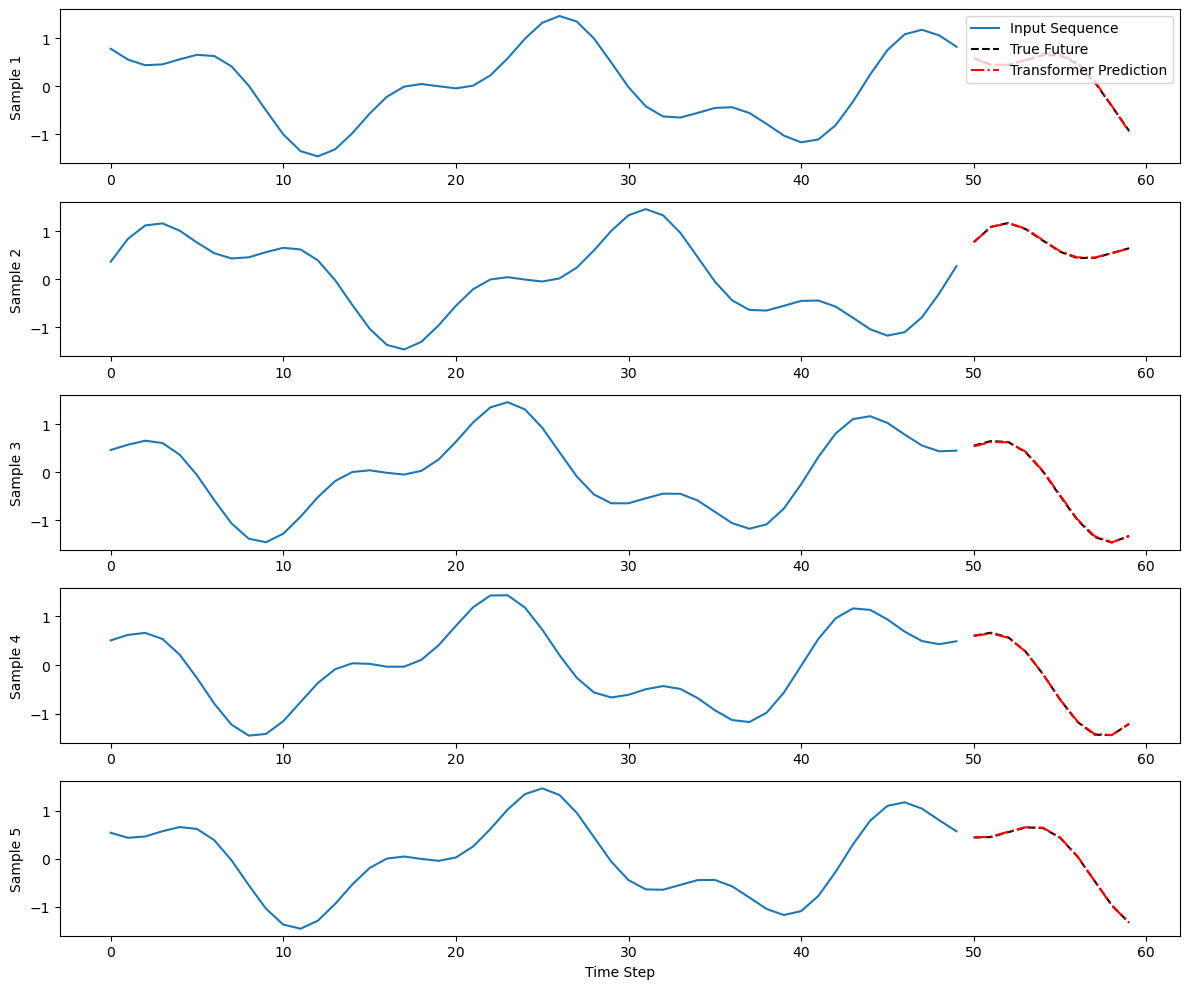

In [22]:
plt.figure(figsize=(12, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(range(50), X_test[i].squeeze(), label="Input Sequence") #.squeeze removes the last dimension so that it is 1-dimensional
    plt.plot(range(50, 60), y_test[i], 'k--', label="True Future")
    plt.plot(range(50, 60), transformer_preds[i], 'r-.', label="Transformer Prediction")
    plt.ylabel(f"Sample {i+1}")
    if i == 0:
        plt.legend(loc="upper right")

plt.xlabel("Time Step")
plt.tight_layout()
plt.show()

### Viewing the attention weights

The `attn_scores` array contains the attention scores for each query-key combination for each attention head.

In [23]:
attn_scores.shape
# (batch_size, num_heads, query_len, key_len)

(5, 4, 50, 50)

The following code plots the attention weights

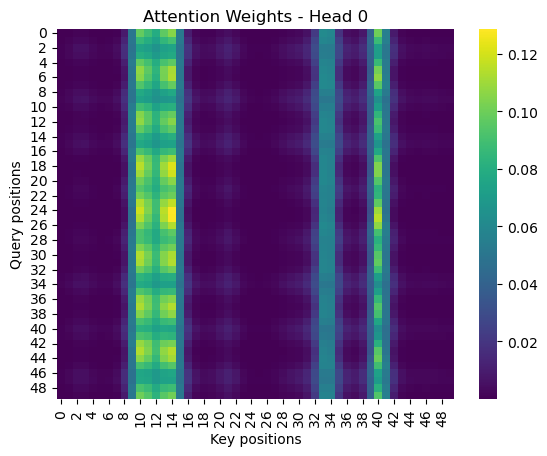

In [24]:
head = 0
sns.heatmap(attn_scores[0, head], cmap='viridis')
plt.title(f"Attention Weights - Head {head}")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

You should see that certain key positions are lit up more indicating that these are important parts of the sequence being used for predictions.

## Bonus: Disabling the positional encoding block

Re-train your transformer model but this time with the `pos_encoding_flag` variable in the `build_transformer_seq2seq_model` set to False. This will disable the positional encoding block. You don't need to plot the attention weights.

In [5]:
# ANSWER: set up and compile model

train_model, analysis_model = build_transformer_seq2seq_model(X_train.shape[1:], d_model=16, num_heads=4, ff_dim=16, output_steps=10, pos_encoding_flag=False)
train_model.compile(optimizer='adam', loss='mse')

NameError: name 'build_transformer_seq2seq_model' is not defined

In [3]:
#  CHATGPT: Build the model

train_model, analysis_model = build_transformer_seq2seq_model(
    input_shape=X_train.shape[1:],
    d_model=16,
    num_heads=4,
    ff_dim=16,
    output_steps=10,
    pos_encoding_flag=False)   # positional encoding DISABLED

NameError: name 'build_transformer_seq2seq_model' is not defined

In [ ]:
#  CHATGPT:  Compile the training model

train_model.compile(
    optimizer='adam',
    loss='mse')

In [2]:
# ANSWER: fit model and calculate predictions

# train_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), batch_size=32, verbose=1)

# transformer_preds, _ = analysis_model.predict(X_test)

NameError: name 'train_model' is not defined

In [ ]:
#  CHATGPT:  Fit the model

history = train_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)


In [1]:
# plot graphs
plt.figure(figsize=(12, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(range(50), X_test[i].squeeze(), label="Input Sequence") #.squeeze removes the last dimension so that it is 1-dimensional
    plt.plot(range(50, 60), y_test[i], 'k--', label="True Future")
    #plt.plot(range(50, 60), lstm_preds[i], 'b:', label="LSTM Prediction")
    plt.plot(range(50, 60), transformer_preds[i], 'r-.', label="Transformer Prediction")
    plt.ylabel(f"Sample {i+1}")
    if i == 0:
        plt.legend(loc="upper right")

plt.xlabel("Time Step")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

You should see the results are poor. While RNNs such as LSTMs process sequences step-by-step where each step depends on the one before, transformers see each input vector as unordered. Positional encodings provide information about the order of each value in the sequence.

## Conclusion

Two neural network architectures are used here for sequence prediction: LSTMs and Transformers.

LSTMs improve on traditional recurrent neural networks (RNNs) by using memory gates that allow them to capture longer-term patterns in sequences.

Transformers, on the other hand, rely on the attention mechanism, enabling them to model dependencies across a sequence more efficiently. With a similar number of parameters, Transformers often perform better and scale more effectively. They also form the foundation of today’s large language models.



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



